# Bayesian Optimisation for Fluid Dynamics

## Wind Farm Yaw Optimisation using BoTorch and FLORIS

## Learning Objectives

By the end of this tutorial you will be able to
- understand when Bayesian Optimisation (BO) should be used,
- explain the role of Gaussian Processes in surrogate modelling,
- understand the exploration–exploitation trade-off,
- implement Bayesian Optimisation using BoTorch,
- apply BO to a fluid dynamics optimisation problem,
- compare BO against conventional random search.

Throughout the tutorial we use a simplified **wind farm yaw optimisation** problem. Although this is considerably cheaper than performing Reynolds-Averaged Navier–Stokes (RANS), Large-Eddy Simulation (LES) or Direct Numerical Simulation (DNS), it captures the essential features of many optimisation problems encountered in computational fluid dynamics.

# 1. Why Bayesian Optimisation?
Many problems in fluid mechanics require optimisation.

Examples include

- aerodynamic shape optimisation,
- active flow control,
- wind farm optimisation,
- turbulence model calibration,
- experimental design,
- boundary condition estimation.

In many of these problems, evaluating the objective function requires running an expensive CFD simulation or performing a physical experiment.

A single evaluation may require

- minutes (steady RANS),
- hours (LES),
- days or weeks (DNS).

Consequently, optimisation algorithms requiring thousands of function evaluations rapidly become computationally infeasible.

Bayesian Optimisation was specifically developed for this setting.

Rather than repeatedly evaluating the expensive objective function, Bayesian Optimisation constructs a probabilistic surrogate model of the objective. This surrogate predicts both

- the expected objective value,
- the uncertainty of that prediction.

The optimisation algorithm then uses this information to determine where the next expensive simulation should be performed.

## Why not use gradient-based optimisation?

Classical optimisation algorithms often rely on gradients.

While gradient-based methods are extremely powerful, they have several limitations in fluid mechanics.

- Adjoint solvers are not always available.
- Commercial CFD software often provides no gradient information.
- Experimental optimisation has no gradients.
- Turbulent objective functions are often noisy.
- Multiple local optima may exist.

Bayesian Optimisation avoids these difficulties by treating the simulator as a **black box**.

Only the objective value is required.

## Advantages and limitations

### Advantages

- Extremely sample efficient
- Naturally handles noisy observations
- Does not require gradients
- Quantifies uncertainty
- Suitable for expensive simulations

### Limitations

- Gaussian Processes scale poorly with dataset size
- Performance deteriorates in high-dimensional spaces
- Assumes relatively smooth objective functions
- Less useful when simulations are already inexpensive


As a rule of thumb, Bayesian Optimisation is most effective when

> $ simulation \; cost >> optimisation \; cost $

# Typical Fluid Dynamics Applications

Bayesian Optimisation has become increasingly common throughout fluid
mechanics.

Examples include

- wind farm control,
- turbine layout optimisation,
- drag reduction,
- airfoil design,
- turbulence model calibration,
- active flow control,
- combustion optimisation,
- mixer design,
- uncertainty quantification.

The same optimisation framework can usually be reused with only minor modifications to the objective function.

# 2. Problem Overview

In this tutorial we consider **wind farm yaw optimisation**.
Upstream turbines create wakes that reduce the power produced by downstream turbines.
By intentionally yawing an upstream turbine away from the incoming wind, the wake can be redirected.
Although the upstream turbine sacrifices a small amount of power, downstream turbines may produce considerably more.

The objective is therefore to maximaise the farm's output power $P_{\mathrm{farm}}$

$$
\max_{\theta_1,\theta_2}
P_{\mathrm{farm}}
$$

where $\theta_1$ and $\theta_2$ are the yaw angles of the first two turbines.

Instead of running expensive LES simulations, we use **FLORIS**, an analytical wake model developed by NREL.
FLORIS evaluates in milliseconds while retaining the key wake interaction physics required for optimisation.
This allows us to focus on understanding Bayesian Optimisation rather than waiting for CFD simulations to complete.

# 3. Bayesian Optimisation
Bayesian Optimisation consists of two components:

#### 1. Surrogate model
Usually a Gaussian Process (GP).
The GP approximates the expensive objective function using all previous
simulations (initial samples).


#### 2. Acquisition function
Uses the GP prediction and uncertainty to determine the next simulation (next targeted smapling point).


#### The optimisation loop becomes

1. Fit Gaussian Process
2. Construct acquisition function
3. Optimise acquisition function
4. Evaluate new CFD simulation
5. Update dataset
6. Repeat


Rather than searching everywhere, BO learns where the optimum is likely to
be and focuses computational effort there.

![BO Diagram](BO_loop.png)

**3.1 Exploration versus Exploitation**

One of the defining features of Bayesian Optimisation is balancing

**Exploration**

- Sample regions where the uncertainty is high.

**Exploitation**

- Sample where the predicted objective is already high.

Good optimisation requires balancing both behaviours.

> This trade-off is controlled by an __Acquisition function__.

## 3.2 Gaussian Process (Surrogate model)

Before applying Bayesian Optimisation to wind farms, it is helpful to understand Gaussian Processes.

A Gaussian Process is a probabilistic regression model.
Instead of predicting a single value, it predicts both:

- a mean,
- a confidence interval.

This uncertainty estimate is what makes Bayesian Optimisation possible.

The Gaussian Process assumes

$$
f(x)\sim GP(m(x),k(x,x'))
$$

where

- $m(x)$ is the mean function,
- $k(x,x')$ is the covariance (kernel).

The kernel determines how rapidly neighbouring points are expected to vary.

In many fluid mechanics optimisation problems, nearby parameters produce similar flow fields, making smooth kernels such as the RBF kernel a good initial choice.

Gaussian Process is explained below using a sinusoidal function as an example before diving into BO.

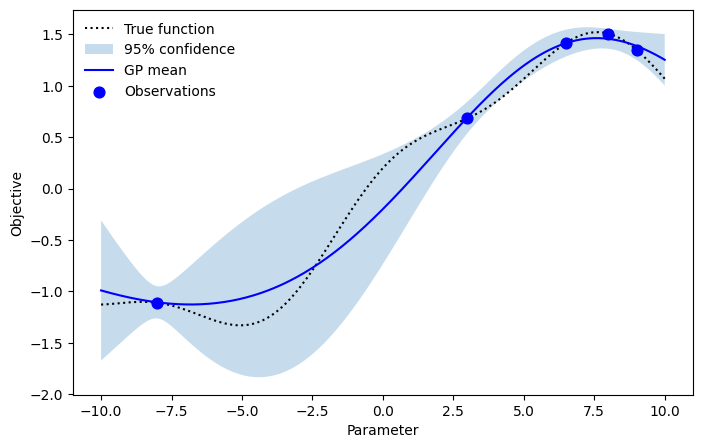

In [1]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

# Synthetic function used only for illustrating GP behaviour
def objective(x):
    return (
        np.sin(0.25*x)
        +0.2*np.cos(0.8*x)
        +0.05*x
    )

# initial sampling points (training data)
train_x = torch.tensor([[-8.0],[3.0],[6.5],[8.0],[9.0]])
train_y = torch.tensor(objective(train_x.numpy())).reshape(-1,1)

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize
from botorch.models.transforms import Standardize

# Define GP model and fit to initial samples
gp = SingleTaskGP(train_x, train_y,
                  input_transform=Normalize(d=1),
                  outcome_transform=Standardize(m=1))
mll = ExactMarginalLogLikelihood(gp.likelihood,gp)
fit_gpytorch_mll(mll)

# Evaluate model across the parameter space
gp.eval()
x = torch.linspace(-10,10,300).unsqueeze(-1)
with torch.no_grad():
    posterior = gp.posterior(x)

mean = posterior.mean.squeeze().numpy()
std = posterior.variance.sqrt().squeeze().numpy()

# Plot the GP model 
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(x, objective(x.numpy()), "k:", label="True function")
ax.fill_between(
    x.squeeze(),
    mean-2*std,
    mean+2*std,
    alpha=0.25,
    label="95% confidence"
)
ax.plot(x, mean, 'b', label="GP mean")
ax.scatter(train_x, train_y, s=60, c="b", marker='o', zorder=3, label="Observations")
ax.set_xlabel("Parameter")
ax.set_ylabel("Objective")
ax.legend(frameon=False)
plt.show()

**3.2.1 Physical interpretation** 

Notice that the Gaussian Process behaves differently in regions with and
without observations.

Near observed data points (sampling point),

- uncertainty is small,
- predictions are accurate.

Between observations,

- uncertainty increases,
- predictions become less certain.

Bayesian Optimisation exploits precisely this uncertainty estimate.

Regions with both

- high predicted objective,
- high uncertainty,

become attractive candidates for future CFD simulations.

> Try changing the observation locations by changing the values in train_x. What effect does this have on the model?

# 4. Wind Farm Optimisation

We now replace the synthetic objective function with a realistic fluid dynamics optimisation problem.

The objective is to maximise the total power generated by a wind farm by adjusting the yaw angles of the two upstream turbines.

Computing this objective using LES or RANS would require solving the governing equations for every candidate yaw configuration. Such an approach would make Bayesian Optimisation prohibitively expensive.

Instead, we use **FLORIS (FLOw Redirection and Induction in Steady-state)**, an open-source engineering wake model developed by the National Renewable Energy Laboratory (NREL).

FLORIS captures

- wake deficit,
- wake expansion,
- wake deflection,
- turbine-turbine interactions,

while evaluating in milliseconds. Although considerably cheaper than CFD, it preserves the optimisation landscape encountered in practical wind farm control problems.

In [2]:
# Core libraries
import torch
import numpy as np
import matplotlib.pyplot as plt

# Gaussian Processes
import gpytorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.models.transforms import Normalize
from botorch.models.transforms import Standardize
from gpytorch.mlls import ExactMarginalLogLikelihood

# FLORIS
from floris import FlorisModel
import floris.flow_visualization as flowviz

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

## 4.1 Wind Farm Configuration

We consider a simple wind farm consisting of three turbines arranged in a row. Only the first two turbines are allowed to yaw. The third turbine remains aligned with the incoming wind.

The optimisation variables are therefore

$$
x=[\theta_1,\theta_2]
$$

where

- $\theta_1$ is the yaw angle of turbine 1
- $\theta_2$ is the yaw angle of turbine 2

The objective is maximise the total wind farm power $P_{\rm farm}$, which is defined as the sum of power generated by each turbine $P_{\rm farm} = \sum_{i=1}^N P_i$
$$
max{P_{\rm farm}(\theta_1,\theta_2)}
$$

where the total wind farm power is computed using FLORIS.

In [3]:
# Load FLORIS model

fli = FlorisModel("gch.yaml")

n_turbines = 3 #no. of tubrines
D = 126        #turbine diameter

x = np.linspace(0, 5*D*n_turbines, n_turbines)
y = np.array([0])

turbine_x,turbine_y = np.meshgrid(x,y)

turbine_x=turbine_x.flatten()
turbine_y=turbine_y.flatten()

fli.set(
    layout_x=turbine_x,
    layout_y=turbine_y,
    wind_directions=[270.0],
    wind_speeds=[8.0],
    turbulence_intensities=[0.06],
)

## Visualising the Baseline Wake

Before optimising, it is useful to inspect the baseline flow. The figure below shows the wake generated when all three turbines operate with zero yaw angle.

Notice how each turbine produces a velocity deficit that propagates downstream and reduces the energy available to subsequent turbines. The purpose of wake steering is to redirect these deficits away from downstream machines.

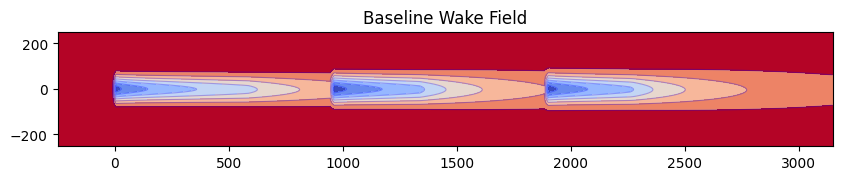

In [4]:
# Zero yaw case

fli.set(yaw_angles=np.zeros((1,3)))
fli.run()

horizontal_plane = fli.calculate_horizontal_plane(height=90)

fig,ax = plt.subplots(figsize=(10,3))

flowviz.visualize_cut_plane(horizontal_plane,ax=ax)

plt.title("Baseline Wake Field")
plt.show()

## Objective Function (Farm's output power)

Bayesian Optimisation (BO) treats the system as a black box.
It does not require any information about the governing equations or the numerical solver.
Instead, the optimiser simply queries the system using different yaw angles and records the resulting power output.
This is one of the main strengths of Bayesian Optimisation:

> **Any system capable of returning an objective value can be optimised.**

The total power generated by the farm for zero yaw angle is calucalted as follows (from FLORIS).

In [5]:
def power_from_floris(fi, yaws, direction=270):

    yaws = yaws.detach().numpy()
    fixed = np.zeros((yaws.shape[0],1))
    yaws = np.hstack([yaws, fixed])

    fi.set(
        yaw_angles=yaws,
        wind_directions=[direction]*len(yaws),
        wind_speeds=[8.0]*len(yaws),
        turbulence_intensities=[0.06]*len(yaws),
    )

    fi.run()
    power = fi.get_farm_power()
    
    return torch.from_numpy(power)


# Evaluate one configuration
test=torch.tensor([[0., 0.]])
power=power_from_floris(fli,test)

print(f"Farm power = {power.item()/1e6:.2f} MW")

Farm power = 3.30 MW


## Exploring the Design Space

Before fitting a Gaussian Process, it is useful to understand the objective function.
The figure below shows the power generated across the two-dimensional yaw parameters space. Considering a range of $-40 ^\circ < [\theta_1,\theta_2] < 40 ^\circ$ with $ \Delta\theta = 5 ^\circ$, resulting in $289$ sampling points. Thus, we will need to run **FLORIS** $289$ times to plot the actual output power, $P_{farm}$, as a function of $\theta_1,\theta_2$. 

In practice this surface would not be available because generating it would require evaluating the simulator thousands of times.
It is shown here purely for educational purposes.

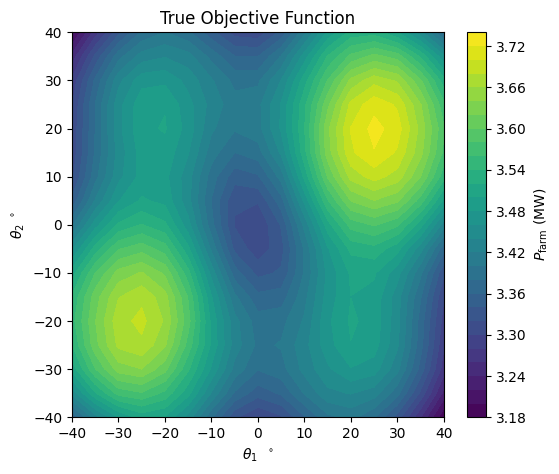

In [6]:
angles = np.linspace(-40, 40, 17)
Y1, Y2 = np.meshgrid(angles, angles)
power = np.zeros_like(Y1)

for i in range(Y1.shape[0]):
    for j in range(Y1.shape[1]):
        x=torch.tensor([[Y1[i,j],Y2[i,j]]],dtype=torch.float64)
        power[i,j]=power_from_floris(fli,x).item()

fig,ax = plt.subplots(figsize=(6,5))

c = ax.contourf(
    Y1,
    Y2,
    power/1e6,
    levels=30
)

plt.colorbar(c, label=r"$P_{\rm farm}$ (MW)")

ax.set_xlabel(r"$\theta_1$  $^\circ$")
ax.set_ylabel(r"$\theta_2$ $^\circ$")

ax.set_title("True Objective Function")

plt.show()

Notice that the optimisation landscape is smooth but nonlinear. There are multiple local maxima arising from wake interactions between the turbines.

BO attempts to locate the global optimum using only a handful of expensive evaluations rather than exhaustively sampling the entire parameter space.

# 5. Initial Design of Experiments

Bayesian Optimisation begins with a number of sampling points, i.e, initial simulations. These initial samples provide enough information for the Gaussian Process to construct its first approximation of the objective function.
Several experimental design strategies are commonly used, including:
- random sampling,
- Latin Hypercube Sampling,
- Sobol sequences.

For simplicity, we use random sampling.

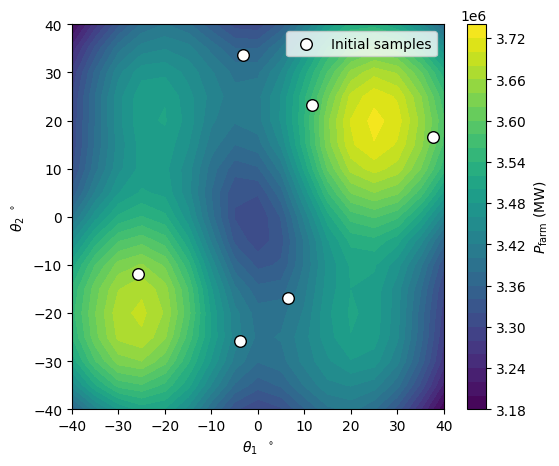

In [7]:
bounds = torch.tensor([[-40.,-40.],[40.,40.]])
n_init = 6
train_x = torch.rand(n_init,2)
train_x = train_x * (bounds[1]-bounds[0]) + bounds[0]
train_y = power_from_floris(fli,train_x).unsqueeze(-1)

fig,ax = plt.subplots(figsize=(6,5))
c = ax.contourf(Y1, Y2, power, levels=30)
plt.colorbar(c, label=r"$P_{\rm farm}$ (MW)")


ax.scatter(
    train_x[:,0],
    train_x[:,1],
    s=70,
    facecolors="white",
    edgecolors="black",
    label="Initial samples"
)

ax.legend()
ax.set_xlabel(r"$\theta_1$  $^\circ$")
ax.set_ylabel(r"$\theta_2$ $^\circ$")
plt.show()

As seen in the previous figure that 6 initial samples (simulations) are clearly insufficient to reconstruct the objective function accurately.

However, BO does not require an accurate global model. Instead, it progressively improves the surrogate, estimated by GP, only in regions that are informative for optimisation.

# 6. Gaussian Process Surrogate Model

We now train a GP using the initial observations.

Before training,

- the inputs are normalised,
- the outputs are standardised.

These transformations improve numerical stability and are standard practice
when training Gaussian Processes.

In [8]:
gp = SingleTaskGP(
    train_x,
    train_y,
    input_transform=Normalize(d=2),
    outcome_transform=Standardize(m=1),
)

mll = ExactMarginalLogLikelihood(
    gp.likelihood,
    gp
)

fit_gpytorch_mll(mll)

ExactMarginalLogLikelihood(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (model): SingleTaskGP(
    (likelihood): GaussianLikelihood(
      (noise_covar): HomoskedasticNoise(
        (noise_prior): LogNormalPrior()
        (raw_noise_constraint): GreaterThan(1.000E-04)
      )
    )
    (mean_module): ConstantMean()
    (covar_module): RBFKernel(
      (lengthscale_prior): LogNormalPrior()
      (raw_lengthscale_constraint): GreaterThan(2.500E-02)
    )
    (outcome_transform): Standardize()
    (input_transform): Normalize()
  )
)

The trained Gaussian Process can now predict the farm power at any yaw configuration together with the associated uncertainty.

# 7. Visualising the Gaussian Process Surrogate

The Gaussian Process provides two quantities:

1. Posterior mean

$$
\mu(x)
$$

which represents the predicted objective value.

2. Posterior standard deviation

$$
\sigma(x)
$$

which quantifies uncertainty.

>The uncertainty estimate is what distinguishes Bayesian Optimisation from many conventional surrogate modelling approaches.


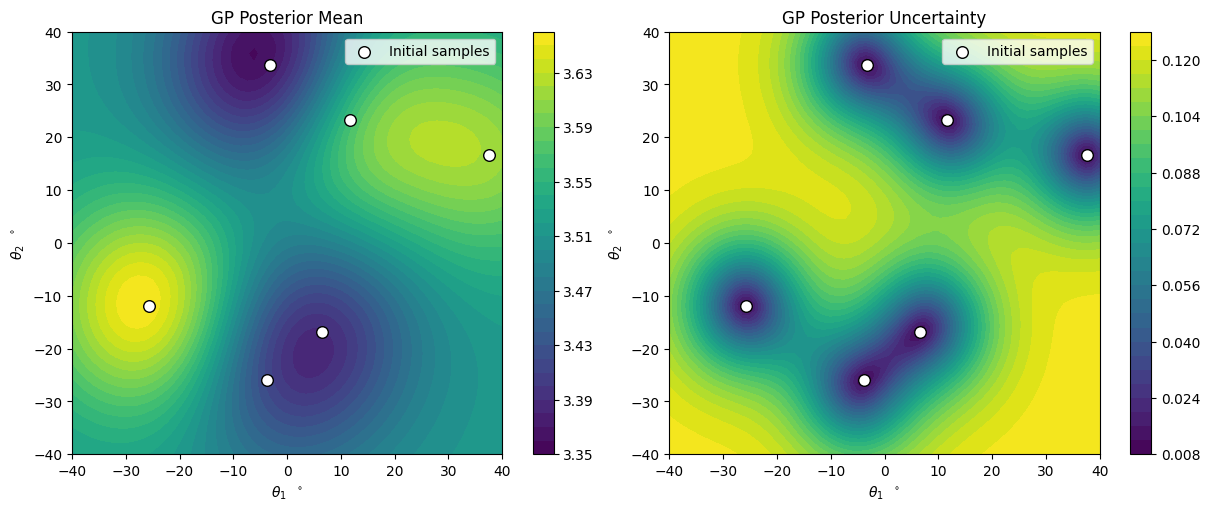

In [9]:
##########################
# Plotting Gaussian Porcess
##########################
def plot_gp_surface(gp, observations):

    n_grid = 60

    x1 = torch.linspace(-40, 40, n_grid)
    x2 = torch.linspace(-40, 40, n_grid)

    X1, X2 = torch.meshgrid(x1,x2,indexing="ij")

    Xgrid = torch.stack(
        [X1.reshape(-1),
         X2.reshape(-1)],
        dim=-1
    )

    gp.eval()

    with torch.no_grad():
        posterior = gp.posterior(Xgrid)
        mean = posterior.mean.reshape(n_grid,n_grid)
        std = posterior.variance.sqrt().reshape(n_grid,n_grid)

    fig,axes = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

    ##########################
    # Plotting Posterior mean
    ##########################
    im0 = axes[0].contourf(
        X1,
        X2,
        mean/1e6,
        levels=30
    )

    axes[0].scatter(
        observations[:,0],
        observations[:,1],
        s=70,
        facecolors="white",
        edgecolors="black",
        label="Initial samples"
    )

    axes[0].set_title("GP Posterior Mean")
    axes[0].set_xlabel(r"$\theta_1$  $^\circ$")
    axes[0].set_ylabel(r"$\theta_2$  $^\circ$")
    axes[0].legend()

    fig.colorbar(im0, ax=axes[0])

    ##########################
    # Plotting Posterior std
    ##########################
    im1 = axes[1].contourf(
        X1,
        X2,
        std/1e6,
        levels=30
    )

    axes[1].scatter(
        observations[:,0],
        observations[:,1],
        s=70,
        facecolors="white",
        edgecolors="black",
        label="Initial samples"
    )

    axes[1].set_title("GP Posterior Uncertainty")
    axes[1].set_xlabel(r"$\theta_1$  $^\circ$")
    axes[1].set_ylabel(r"$\theta_2$  $^\circ$")
    axes[1].legend()

    fig.colorbar(im1,ax=axes[1])

    plt.show()

 
plot_gp_surface(gp, train_x)

## Interpretation

The left figure represents the optimiser's current belief regarding the mean objective function.
The right figure represents uncertainty.

> Notice that uncertainty is lowest near previously evaluated (initial samples) points and highest in the unexplored regions.

An effective optimisation strategy should consider both pieces of information.
- Sampling only where the mean is high risks becoming trapped in local optima.
- Sampling only where uncertainty is high wastes expensive CFD evaluations.

Bayesian Optimisation addresses this challenge through the __acquisition function__.

# 8. Acquisition Functions

Acquisition functions determine where the next simulation should be performed.

Unlike the CFD model, acquisition functions are inexpensive to evaluate.

Therefore we can optimise the acquisition function many times to determine the next expensive CFD simulation.

Common acquisition functions include:

- Upper Confidence Bound (UCB)
- Expected Improvement (EI)
- Probability of Improvement (PI)

Although many other acquisition functions exist, these three provide a useful introduction to the exploration–exploitation trade-off.

## 8.1 Upper Confidence Bound (UCB)

UCB is defined as

$$
\alpha_{UCB}(x)
=
\mu(x)
+
\sqrt{\beta}\sigma(x)
$$

where

- μ(x) is the GP mean
- σ(x) is the GP uncertainty

and β controls exploration.

>Large β: more exploration
>
>Small β: more exploitation

UCB is particularly popular in engineering optimisation because the exploration parameter can be controlled directly.

In [10]:
from botorch.acquisition import UpperConfidenceBound

beta = 8.0

UCB = UpperConfidenceBound(
    model=gp,
    beta=beta
)

## 8.2 Expected Improvement (EI)

Expected Improvement measures the expected improvement over the current best observation.

If $f^*$ denotes the best objective value observed so far, EI quantifies the expected gain obtained by sampling a new location.

Expected Improvement is often more conservative than UCB and can converge rapidly once promising regions have been identified.

In [11]:
from botorch.acquisition import LogExpectedImprovement

EI = LogExpectedImprovement(
    model=gp,
    best_f=train_y.max()
)

## 8.3 Probability of Improvement (PI)

PI evaluates the probability that a candidate point will outperform the current best solution.

Although simple and intuitive, PI frequently over-exploits promising regions and may become trapped in local optima.

For this reason UCB and EI are generally preferred in fluid mechanics applications.

In [12]:
from botorch.acquisition import ProbabilityOfImprovement

PI = ProbabilityOfImprovement(
    model=gp,
    best_f=train_y.max()
)

# Visualising Acquisition Functions

The figures below show how different acquisition functions assign value throughout the design space.
Bright regions indicate locations that the optimiser considers promising.

Notice that acquisition functions are not trying to approximate the objective function.
Instead they are attempting to identify where __information is most valuable__.

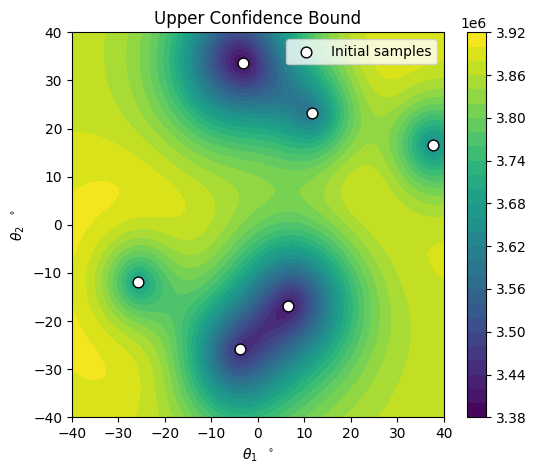

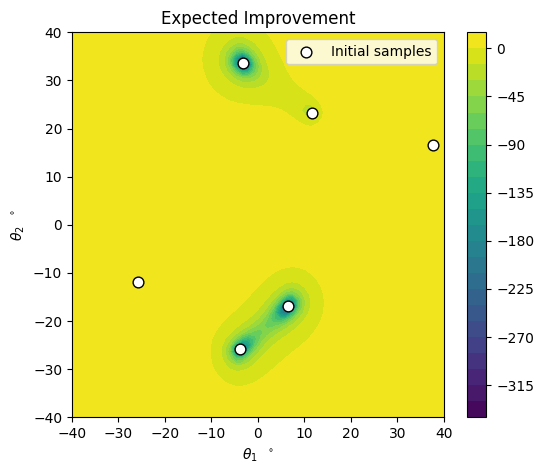

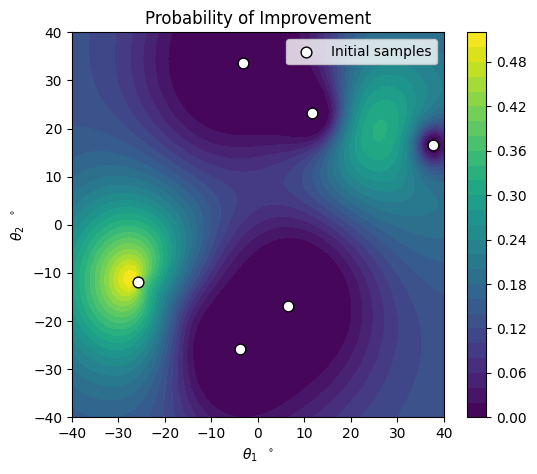

In [13]:
################################
# Plotting Acquisution Functions
################################
def plot_acquisition(acq, title):

    n_grid = 60
    x1 = torch.linspace(-40,40,n_grid)
    x2 = torch.linspace(-40,40,n_grid)
    X1,X2 = torch.meshgrid(
        x1,
        x2,
        indexing="ij"
    )

    Xgrid = torch.stack(
        [
            X1.reshape(-1),
            X2.reshape(-1)
        ],
        dim=-1
    )

    acq.eval()

    with torch.no_grad():
        values = acq(Xgrid.unsqueeze(1))

    values = values.reshape(n_grid, n_grid)

    fig, ax = plt.subplots(figsize=(6,5))

    im = ax.contourf(X1, X2, values, levels=30)

    ax.scatter(
        train_x[:,0],
        train_x[:,1],
        c="white",
        edgecolors="black",
        s=60,
        label="Initial samples"
    )

    ax.set_xlabel(r"$\theta_1$  $^\circ$")
    ax.set_ylabel(r"$\theta_2$  $^\circ$")
    ax.set_title(title)
    ax.legend()
    plt.colorbar(im)
    plt.show()


plot_acquisition(UCB, "Upper Confidence Bound")
plot_acquisition(EI, "Expected Improvement")
plot_acquisition(PI, "Probability of Improvement")

## Comparing Acquisition Functions

Each acquisition function reflects a different optimisation strategy.

- __UCB__:  Aggressive exploration.
High uncertainty regions remain attractive even if the predicted objective value is modest.

- __EI__:  Balanced behaviour.
Seeks locations likely to improve upon the current best solution.

- __PI__:  Aggressive exploitation.
Often concentrates around regions already believed to be optimal.

In practice, UCB and EI are the most common choices for expensive CFD optimisation problems.

# Selecting the Next Simulation (next sampling point)

The next CFD simulation (sampling point) is obtained by maximising the acquisition function.

This optimisation is inexpensive because evaluating the acquisition function requires only a Gaussian Process prediction rather than a CFD simulation. Typical gradient based optimisation approaches can be used.

Next evaluation:
tensor([[-40.0000,   0.0676]])


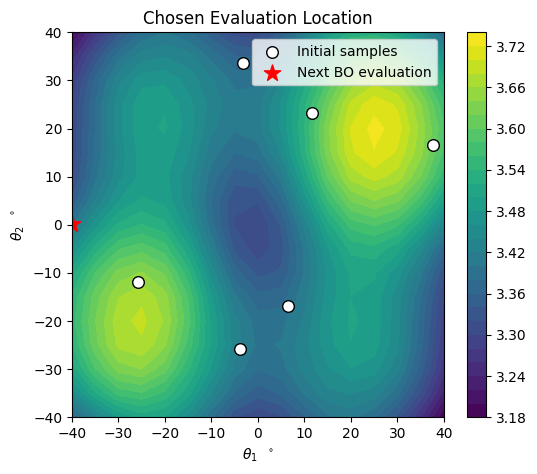

In [14]:
from botorch.optim import optimize_acqf

candidate, acq_value = optimize_acqf(
    UCB,
    bounds=bounds,
    q=1, # This is the number of candidates returned. q>1 useful for running parallel experiments
    num_restarts=20,
    raw_samples=200,
)

print("Next evaluation:")
print(candidate)

fig,ax = plt.subplots(
    figsize=(6,5)
)

im = ax.contourf(
    Y1, Y2,
    power/1e6,
    levels=30
)

ax.scatter(
    train_x[:,0],
    train_x[:,1],
    c="white",
    edgecolors="black",
    s=70,
    label="Initial samples"
)

ax.scatter(
    candidate[0,0],
    candidate[0,1],
    c="red",
    marker="*",
    s=150,
    label="Next BO evaluation"
)

ax.legend()
ax.set_xlabel(r"$\theta_1$  $^\circ$")
ax.set_ylabel(r"$\theta_2$  $^\circ$")
ax.set_title("Chosen Evaluation Location")
plt.colorbar(im)

plt.show()

The point returned above is where the optimiser believes the next simulation should be performed.

> Importantly:
>
> - the optimiser has not evaluated FLORIS there yet,
> - the location was chosen entirely from the GP prediction and   uncertainty.

This is the key idea underlying Bayesian Optimisation.

## Performing the New Simulation

We now evaluate the expensive objective function at the candidate point.

In a real application this might correspond to:

- a CFD simulation,
- a wind tunnel experiment,
- a field measurement.

Here we simply evaluate FLORIS.

In [15]:
new_y = power_from_floris(
    fli,
    candidate
).unsqueeze(-1)

print(new_y)

tensor([[3394757.3061]])


The new observation can then be added to the dataset.

In [16]:
train_x = torch.cat(
    [train_x, candidate]
)

train_y = torch.cat(
    [train_y, new_y]
)

# 9. Bayesian Optimisation Loop

We now combine all of the previous components into the complete Bayesian Optimisation algorithm.

At each iteration the algorithm performs the following steps:

1. Fit a Gaussian Process to the existing observations.
2. Construct an acquisition function.
3. Optimise the acquisition function.
4. Evaluate the expensive simulator.
5. Update the training data.

The process continues until the available computational budget has been exhausted or a specific convergance criteria is met.

In [17]:
from botorch.optim import optimize_acqf
from botorch.acquisition import UpperConfidenceBound

n_iterations = 20
history = []

for i in range(n_iterations):

    gp = SingleTaskGP(
        train_x,
        train_y,
        input_transform=Normalize(d=2),
        outcome_transform=Standardize(m=1),
    )

    mll = ExactMarginalLogLikelihood(
        gp.likelihood,
        gp,
    )

    fit_gpytorch_mll(mll)

    acquisition = UpperConfidenceBound(model=gp, beta=8.0)

    candidate, _ = optimize_acqf(
        acquisition,
        bounds=bounds,
        q=1,
        num_restarts=20,
        raw_samples=200,
    )

    new_y = power_from_floris(
        fli,
        candidate,
    ).unsqueeze(-1)

    train_x = torch.cat([train_x, candidate])
    train_y = torch.cat([train_y, new_y])

    history.append(train_y.max().item())

    print(
        f"Iteration {i+1:2d}   "
        f"Best Power = {history[-1]/1e6:.4f} MW"
    )

Iteration  1   Best Power = 3.6576 MW
Iteration  2   Best Power = 3.6576 MW
Iteration  3   Best Power = 3.6576 MW
Iteration  4   Best Power = 3.6576 MW
Iteration  5   Best Power = 3.6718 MW
Iteration  6   Best Power = 3.6718 MW
Iteration  7   Best Power = 3.6718 MW
Iteration  8   Best Power = 3.7237 MW
Iteration  9   Best Power = 3.7237 MW
Iteration 10   Best Power = 3.7237 MW
Iteration 11   Best Power = 3.7237 MW
Iteration 12   Best Power = 3.7245 MW
Iteration 13   Best Power = 3.7245 MW
Iteration 14   Best Power = 3.7271 MW
Iteration 15   Best Power = 3.7274 MW
Iteration 16   Best Power = 3.7276 MW
Iteration 17   Best Power = 3.7276 MW
Iteration 18   Best Power = 3.7276 MW
Iteration 19   Best Power = 3.7276 MW
Iteration 20   Best Power = 3.7276 MW


## Convergence History

The figure below shows the best solution discovered throughout the optimisation.
Notice that Bayesian Optimisation does not necessarily improve every iteration.
Some iterations deliberately explore uncertain regions in order to improve the surrogate model.

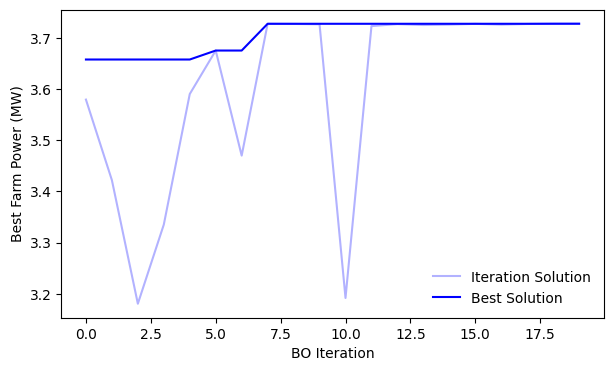

In [45]:
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(train_y[-len(history):]/1e6, 'b', alpha=0.3, label='Iteration Solution')
ax.plot(np.array(history)/1e6, 'b', label='Best Solution')

ax.legend(frameon=False)
ax.set_xlabel("BO Iteration")
ax.set_ylabel("Best Farm Power (MW)")

plt.show()

# 10. Final Solution

Once the optimisation has been run we can visualise the GP surface again after the final iteration.
We can see that:

- The optimisation has explored the parameter space.
- Uncertainty has been reduced in areas of high mean predictions.
- Uncertainty remains higher in areas with low mean predictions.
- The optimisation has focussed evaluations around the predicted peak to refine the optimum.

The final optimal solution for the wind farm wake steering can be visualised.



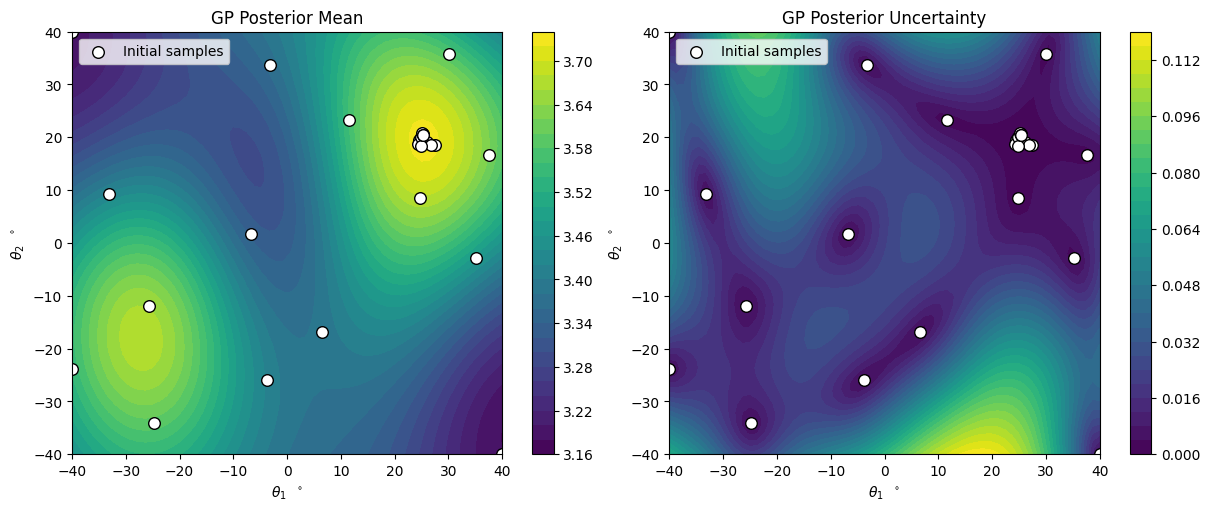

Optimal yaw angles: tensor([25.3497, 20.4030])
Maximum power: 3.727 MW


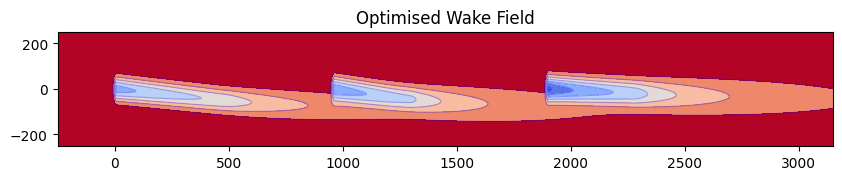

In [46]:

plot_gp_surface(gp, train_x)

best_idx = train_y.argmax()
best_angles = train_x[best_idx]
best_power = train_y[best_idx].item()

print(f"Optimal yaw angles: {best_angles}")
print(f"Maximum power: {best_power/1e6:.3f} MW")

power_from_floris(fli, best_angles.unsqueeze(0), 270)

# fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharex=False)
fig,ax = plt.subplots(figsize=(10,3))
horizontal_plane = fli.calculate_horizontal_plane(height=90.0)
flowviz.visualize_cut_plane(horizontal_plane, ax=ax)
plt.title("Optimised Wake Field")

plt.show()

# 11. Comparison with Random Search

Bayesian Optimisation is often described as being "sample efficient."
But what does this actually mean?

To answer this question we compare Bayesian Optimisation with pure random search using exactly the same number of expensive FLORIS evaluations.

In [ ]:
n_random = len(history)
random_best = []
best = -np.inf
all_y = []
torch.manual_seed(1)

for i in range(n_random):
    x = torch.rand(1,2)
    x = x*(bounds[1]-bounds[0])+bounds[0]

    y = power_from_floris(fli, x).item()
    best = max(best,y)

    random_best.append(best)
    all_y.append(y)


fig,ax = plt.subplots(figsize=(7,4))

ax.plot(train_y[-len(history):]/1e6, 'b', alpha=0.3, label='BO Iteration')
ax.plot(np.array(history)/1e6, 'b', label="BO Best")

ax.plot(np.array(all_y)/1e6, 'r', alpha=0.3, label='Random Iteration')
ax.plot(np.array(random_best)/1e6, 'r', label="Random Best")

ax.set_xlabel("Function Evaluations")
ax.set_ylabel("Farm Power (MW)")
ax.legend(frameon=False)


plt.show()

### Discussion

Random search spends many evaluations exploring poor regions of the design space.
Bayesian Optimisation instead learns where promising regions are located and allocates future simulations accordingly.
This intelligent sampling strategy explains why Bayesian Optimisation often requires an order of magnitude fewer expensive CFD simulations.

# 12. Practical Considerations

Bayesian Optimisation is extremely effective when

- simulations are expensive,
- the number of design variables is relatively small,
- gradients are unavailable.

However, several limitations should be recognised.

## Curse of Dimensionality

Standard Gaussian Processes become increasingly inefficient beyond approximately 15–20 optimisation variables.

Higher-dimensional optimisation often requires

- additive kernels,
- trust-region BO,
- latent-space optimisation,
- neural surrogate models.


## Computational Cost

GP regression scales approximately as

$$ \mathcal{O}(N^3) $$

where N is the number of observations.

Consequently Bayesian Optimisation should only be used when simulator evaluations dominate the computational cost.


## Constraints

Engineering optimisation problems frequently involve constraints such as

- minimum turbine spacing,
- actuator limits,
- structural requirements,
- manufacturing constraints.

Modern BO libraries support constrained optimisation directly.


## Multi-objective Optimisation

In many engineering applications multiple competing objectives exist,
including

- power,
- structural loading,
- acoustic noise,
- fatigue.

Bayesian Optimisation can be extended to approximate the Pareto front of such problems.

# 13. Further Exercises

**Exercise 1**

Replace Upper Confidence Bound with Expected Improvement.

---

**Exercise 2**

Investigate how changing β affects convergence.

---

**Exercise 3**

Increase the number of turbines.

Does optimisation become more difficult?

---

**Exercise 4**

Add Gaussian noise to the objective function.

How robust is Bayesian Optimisation?

---

**Exercise 5**

Replace the RBF kernel with a Matérn kernel.

Compare the resulting surrogate.

---

**Exercise 6**

Optimise turbine locations rather than yaw angles.

How many function evaluations are required?

---

**Exercise 7**

Compare Bayesian Optimisation against

- Random Search
- CMA-ES
- Differential Evolution

using the same computational budget.


## Further Resources:
- [A Tutorial on Bayesian Optimization of Expensive Cost Functions](https://doi.org/10.48550/arXiv.1012.2599)
- [Taking the Human Out of the Loop: A Review of Bayesian Optimization](https://doi.org/10.1109/JPROC.2015.2494218)
- [BOTorch Tutorials](https://botorch.org/docs/tutorials/)

# Key Takeaways

In this tutorial you have learned how Bayesian Optimisation can be used to solve expensive optimisation problems encountered in fluid mechanics.

The key ideas are:

- Bayesian Optimisation is designed for expensive black-box optimisation.

- Gaussian Processes provide both predictions and uncertainty estimates.

- Acquisition functions balance exploration and exploitation.

- Bayesian Optimisation often requires dramatically fewer simulations than
  random search.

- The methodology is directly applicable to many CFD optimisation problems,
  including

  - wind farm control,
  - aerodynamic design,
  - turbulence model calibration,
  - active flow control,
  - experimental optimisation.

Although this tutorial employed FLORIS as an efficient engineering model, exactly the same workflow can be coupled to higher-fidelity simulations such as RANS, LES or DNS whenever computational resources permit.

Bayesian Optimisation has become an increasingly important tool within fluid mechanics because it enables intelligent decision making under limited computational budgets while naturally accounting for uncertainty.